Before you submit this assignment, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel$\rightarrow$Restart) and then **run all cells** (in the menubar, select Cell $\rightarrow$ Run All).

Make sure you fill in any place that says `YOUR CODE HERE` or "YOUR ANSWER HERE".

# ES98E Assignment 6 - Neural ODEs and PDEs

## Workshop Aims

- Understand how differentiable ODE solvers enable gradient-based parameter estimation
- Implement Neural ODEs to learn unknown dynamics from data
- Apply neural network methods to solve partial differential equations

**Note**: *The maximum available points for this assignment is 120: 100 points for the core material that everyone is expected to attempt, and 20 points for extension material which is optional, but assessed. The highest percentage you could get on this assignment without attempting the extension material is 100/120 = 83.3%*

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import equinox as eqx

import diffrax
from diffrax import diffeqsolve, ODETerm, Tsit5, SaveAt

from optax import adam
from tqdm.auto import tqdm

from jax import config
config.update("jax_enable_x64", True)     # use double rather than single precision floats
config.update('jax_platform_name', 'cpu') # use CPU rather than GPU

# Customize default plotting style
%matplotlib inline
import seaborn as sns
sns.set_context('talk')

In [2]:
plt.rcParams["figure.figsize"] = (10, 6)

## Part 1: Neural ODEs with Lotka-Volterra Dynamics

In Lecture 6 you saw how differentiable ODE solvers can be combined with neural networks to learn dynamics from data. Here we'll apply these ideas to the classic Lotka-Volterra predator-prey model, first recovering known parameters, then learning unknown dynamics with a Neural ODE.

The Lotka-Volterra equations describe predator-prey population dynamics and are a classic example of a nonlinear ODE system:

$$
\begin{align}
\frac{\mathrm{d}x_1}{\mathrm{d}t} &= \alpha x_1 - \beta x_1 x_2 \\
\frac{\mathrm{d}x_2}{\mathrm{d}t} &= -\gamma x_2 + \delta x_1 x_2
\end{align}
$$

where:
- $x_1$ is the prey population density
- $x_2$ is the predator population density
- $\alpha$ is the prey growth rate
- $\beta$ is the predation rate
- $\gamma$ is the predator death rate
- $\delta$ is the predator reproduction rate from consuming prey

We will use the true parameters $\alpha = 1.5$, $\beta = 1.0$, $\gamma = 3.0$, $\delta = 1.0$ with initial conditions $x_1(0) = 1.0$, $x_2(0) = 1.0$.

### Question 1.a

**Implement the Lotka-Volterra equations as a function compatible with diffrax.**

Your function should take time `t`, state vector `y` (containing $[x_1, x_2]$), and `args` (a dictionary with keys `'alpha'`, `'beta'`, `'gamma'`, `'delta'`), and return the derivatives $[\dot{x}_1, \dot{x}_2]$.

<div align="right">[5 points]</div>

In [3]:
true_params = {'alpha': 1.5, 'beta': 1.0, 'gamma': 3.0, 'delta': 1.0}
y0 = jnp.array([1.0, 1.0])

def lotka_volterra(t, y, args):
    """
    Lotka-Volterra predator-prey dynamics.

    Args:
        t: time (not used, but required by diffrax)
        y: state vector [prey, predator]
        args: dict with 'alpha', 'beta', 'gamma', 'delta'

    Returns:
        derivatives [d(prey)/dt, d(predator)/dt]
    """
    x1, x2 = y
    alpha = args["alpha"]
    beta = args["beta"]
    gamma = args["gamma"]
    delta = args["delta"]
    dx_1 = alpha * x1 - (beta * x1 * x2)
    dx_2 = -gamma * x2 + (delta * x1 * x2)

    return jnp.array([dx_1, dx_2])
    

In [4]:
# Test the implementation
dy = lotka_volterra(0.0, jnp.array([1.0, 1.0]), true_params)
assert dy.shape == (2,)
assert jnp.abs(dy[0] - 0.5).max() < 1e-6   # alpha*1 - beta*1*1 = 1.5 - 1.0 = 0.5
assert jnp.abs(dy[1] - (-2.0)).max() < 1e-6  # -gamma*1 + delta*1*1 = -3.0 + 1.0 = -2.0

dy2 = lotka_volterra(0.0, jnp.array([2.0, 0.5]), true_params)
assert jnp.abs(dy2[0] - 2.0).max() < 1e-6   # 1.5*2 - 1.0*2*0.5 = 3.0 - 1.0 = 2.0
assert jnp.abs(dy2[1] - (-0.5)).max() < 1e-6  # -3.0*0.5 + 1.0*2*0.5 = -1.5 + 1.0 = -0.5

### Question 1.b

**Solve the Lotka-Volterra system and plot the population dynamics.**

Use diffrax to solve the ODE system from $t=0$ to $t=15$ with the true parameters and initial conditions provided above. Create a plot showing both prey and predator populations as functions of time.

<div align="right">[5 points]</div>

In [5]:
def solve_lv(params, y0, t_span, dt0=0.01, saveat_ts=None):
    """
    Solve the Lotka-Volterra system.

    Args:
        params: dict with 'alpha', 'beta', 'gamma', 'delta'
        y0: initial conditions [prey0, predator0] as a length-2 JAX array
        t_span: tuple (t0, t1)
        dt0: initial timestep guess
        saveat_ts: times at which to save solution (optional)

    Returns:
        diffrax solution object
    """
    t0, t1 = t_span

    term = ODETerm(lotka_volterra)
    solver = Tsit5()

    if saveat_ts is not None:
        saveat = SaveAt(ts=saveat_ts)
    else:
        SaveAt(t1=True)

    sol = diffeqsolve(
        term,
        solver,
        t0=t0,
        t1=t1,
        dt0=dt0,
        y0=y0,
        args=params,
        saveat=saveat,
    )
    return sol

# Generate reference data
t_data = jnp.linspace(0, 15, 200)
ref_solution = solve_lv(true_params, y0, (0, 15), saveat_ts=t_data)
ref_y = ref_solution.ys

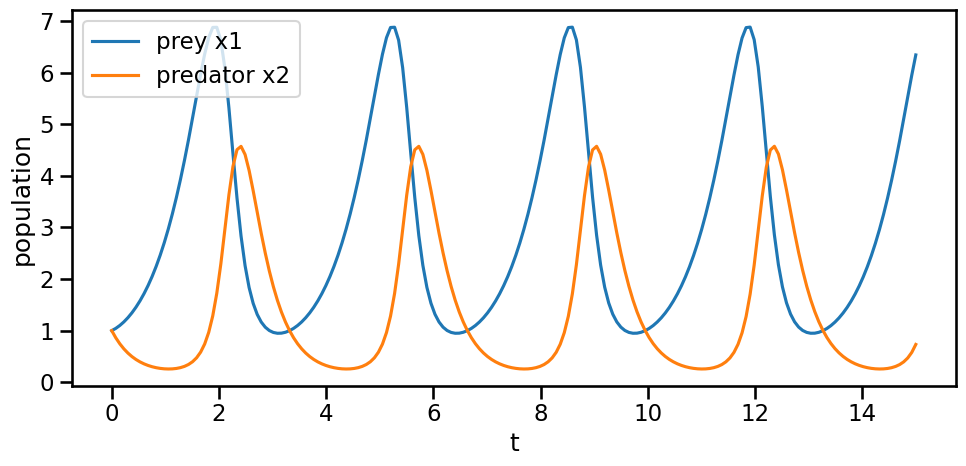

In [6]:
# Extract + convert for matplotlib
ts = np.asarray(ref_solution.ts)
ys = np.asarray(ref_solution.ys)   # shape (T, 2)

prey = ys[:, 0]
pred = ys[:, 1]

# Time series plot
plt.figure(figsize=(10, 5))
plt.plot(ts, prey, label="prey x1")
plt.plot(ts, pred, label="predator x2")
plt.xlabel("t")
plt.ylabel("population")
plt.legend()
plt.tight_layout()
plt.show()

### Question 1.c

**Implement subtrajectory batching for stochastic gradient descent.**

When training Neural ODEs, we often use subtrajectories rather than the full time series. This involves:
1. Randomly sampling starting times from the full trajectory
2. Extracting short subtrajectories of fixed length from these starting points
3. Using these batches for gradient descent

Using subtrajectories is the key to implementing stochastic gradient descent (SGD) for time series data where consecutive points are correlated — each subtrajectory acts as an independent training example.

*Hint:* `batch_t` should be a **relative** time array that always starts from 0 (i.e. the elapsed time within each subtrajectory, not absolute times from the original data).

Complete the `get_batch()` function below that samples `batch_size` random subtrajectories of length `subtraj_length` from the reference data.

<div align="right">[10 points]</div>

In [7]:
def get_batch(key, t_data, y_data, batch_size=16, subtraj_length=20):
    """
    Sample random subtrajectories for training.

    Args:
        key: JAX random key
        t_data: full time array
        y_data: full solution array [n_times, 2]
        batch_size: number of subtrajectories to sample
        subtraj_length: length of each subtrajectory

    Returns:
        batch_t: time points for subtrajectories [subtraj_length]
        batch_y0: initial conditions for each subtrajectory [batch_size, 2]
        batch_y: target trajectories [subtraj_length, batch_size, 2]
    """
    n_times = t_data.shape[0]
    max_start = n_times - subtraj_length  # inclusive
    start_idx = jax.random.randint(key, (batch_size,), minval=0, maxval=max_start + 1)

    offsets = jnp.arange(subtraj_length)
    idx = start_idx[:, None] + offsets[None, :]

    y_windows = y_data[idx]
    batch_y0 = y_windows[:, 0, :]
    batch_y = jnp.swapaxes(y_windows, 0, 1)

    dt = t_data[1] - t_data[0]
    batch_t = dt * jnp.arange(subtraj_length)

    return batch_t, batch_y0, batch_y

In [8]:
key = jax.random.PRNGKey(42)
batch_t, batch_y0, batch_y = get_batch(key, t_data, ref_y, batch_size=8, subtraj_length=15)

assert batch_t.shape == (15,)
assert batch_y0.shape == (8, 2)
assert batch_y.shape == (15, 8, 2)
assert jnp.allclose(batch_y[0], batch_y0)  # First point should match initial conditions

### Question 1.d

**Train the model to recover the Lotka-Volterra parameters from data.**

Now we will pretend we don't know the true parameters and try to recover them from the data. Starting from an initial guess, use gradient descent to optimise the parameters to match the observed trajectories.

Complete the `loss_fn()` function below. The training loop is provided for you. The loss function should compare predicted trajectories (obtained by solving the ODE with current parameters) to the target subtrajectories.

*Hints:* i
- You'll need to use the provided `solve_batch()` function which used `jax.vmap` to solve the ODE for each initial condition in the batch.
- `t_span` should be a tuple of just two values `(t_start, t_end)`, not a full range of time points. The intermediate save points are passed separately via `saveat_ts`.

<div align="right">[15 points]</div>

In [9]:
# Starting guess for parameters (deliberately wrong)
init_params = {'alpha': 1.0, 'beta': 0.5, 'gamma': 2.0, 'delta': 0.5}

def solve_batch(params, y0_batch, t_span, saveat_ts):
    """Solve ODE for a batch of initial conditions."""
    def solve_single(y0):
        sol = solve_lv(params, y0, t_span, saveat_ts=saveat_ts)
        return sol.ys
    return jax.vmap(solve_single)(y0_batch)

def loss_fn(params, batch_t, batch_y0, batch_y_target):
    """
    Compute MSE loss between predicted and target trajectories.

    Args:
        params: dict of ODE parameters
        batch_t: time points [subtraj_length]
        batch_y0: initial conditions [batch_size, 2]
        batch_y_target: target trajectories [subtraj_length, batch_size, 2]

    Returns:
        scalar loss value
    """
    t_span = (batch_t[0], batch_t[-1])
    pred = solve_batch(params, batch_y0, t_span, saveat_ts=batch_t)
    pred = jnp.swapaxes(pred, 0, 1)

    return jnp.mean((pred - batch_y_target) ** 2)

# Training loop
learning_rate = 0.1
n_steps = 200
batch_size = 16
subtraj_length = 20

# Convert params dict to array for optimization
param_names = ['alpha', 'beta', 'gamma', 'delta']
params_array = jnp.array([init_params[k] for k in param_names])

def params_to_dict(params_array):
    return {k: params_array[i] for i, k in enumerate(param_names)}

def loss_wrapper(params_array, batch_t, batch_y0, batch_y):
    return loss_fn(params_to_dict(params_array), batch_t, batch_y0, batch_y)

optim = adam(learning_rate)
opt_state = optim.init(params_array)

@jax.jit
def make_step(params_array, opt_state, batch_t, batch_y0, batch_y):
    loss_value, grads = jax.value_and_grad(loss_wrapper)(params_array, batch_t, batch_y0, batch_y)
    updates, opt_state = optim.update(grads, opt_state, params_array)
    params_array = params_array + updates  # optax returns negative gradients
    return params_array, opt_state, loss_value

# Training history
loss_history = []
param_history = {k: [] for k in param_names}

key = jax.random.PRNGKey(0)
for step in tqdm(range(n_steps)):
    key, subkey = jax.random.split(key)
    batch_t, batch_y0, batch_y = get_batch(subkey, t_data, ref_y, batch_size, subtraj_length)

    params_array, opt_state, loss_value = make_step(params_array, opt_state, batch_t, batch_y0, batch_y)

    loss_history.append(float(loss_value))
    for i, k in enumerate(param_names):
        param_history[k].append(float(params_array[i]))

    if step % 50 == 0:
        print(f"Step {step}: loss = {loss_value:.6f}")

learned_params = params_to_dict(params_array)
print("\nLearned parameters:")
for k in param_names:
    print(f"  {k}: {learned_params[k]:.4f} (true: {true_params[k]:.4f})")

  0%|          | 0/200 [00:00<?, ?it/s]

Step 0: loss = 2.307761
Step 50: loss = 0.005066
Step 100: loss = 0.000014
Step 150: loss = 0.000000

Learned parameters:
  alpha: 1.5000 (true: 1.5000)
  beta: 1.0000 (true: 1.0000)
  gamma: 3.0000 (true: 3.0000)
  delta: 1.0000 (true: 1.0000)


In [10]:
# Check that parameters are reasonably close to true values
for k in param_names:
    assert abs(learned_params[k] - true_params[k]) < 0.5, f"Parameter {k} not recovered accurately"

### Question 1.e

**Plot the training progress and compare the learned solution to the true solution.**

Create a plot with three subplots showing:
1. Training loss and parameter values over training steps
2. Comparison of the true solution and the solution with learned parameters
3. Test extrapolation: solve the learned system from $t=0$ to $t=25$ and compare to the true solution

<div align="right">[10 points]</div>

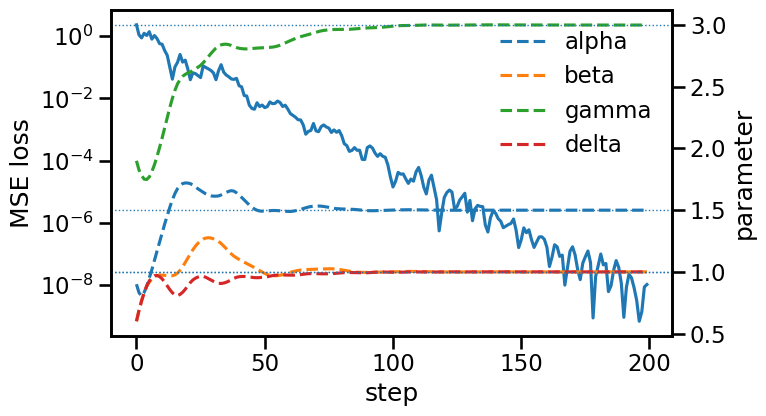

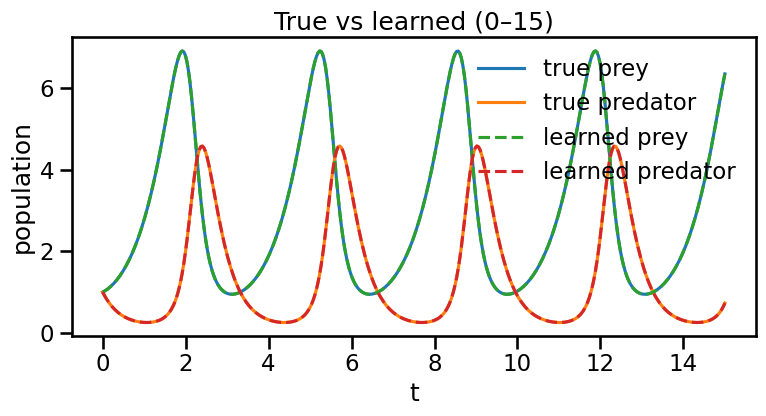

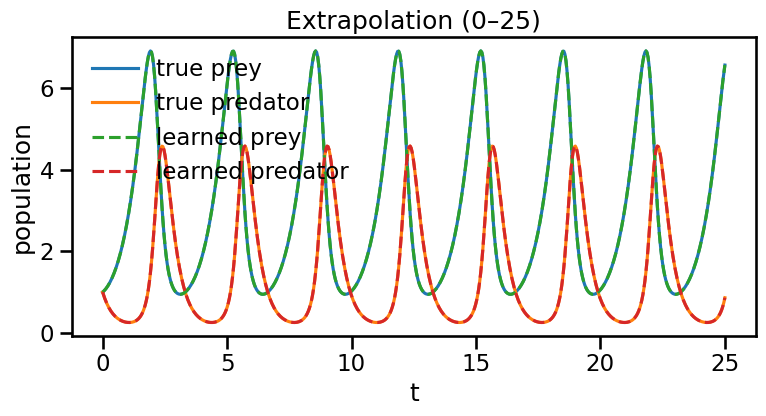

In [11]:
# training loss and params over steps
steps = np.arange(len(loss_history))
losses = np.asarray(loss_history, dtype=float)
P = np.stack([param_history[k] for k in param_names], axis=1)
trueP = np.array([true_params[k] for k in param_names], dtype=float)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(steps, losses)
ax.set_yscale("log")
ax.set_xlabel("step")
ax.set_ylabel("MSE loss")
ax2 = ax.twinx()
for i, k in enumerate(param_names):
    ax2.plot(steps, P[:, i], "--", label=k)
    ax2.axhline(trueP[i], linestyle=":", linewidth=1)
ax2.set_ylabel("parameter")
ax2.legend(frameon=False, loc="upper right")
plt.tight_layout()
plt.show()

# true vs learned
ts = jnp.linspace(0.0, 15.0, 400)
sol_true = solve_lv(true_params, y0, (ts[0], ts[-1]), saveat_ts=ts)
sol_learn = solve_lv(learned_params, y0, (ts[0], ts[-1]), saveat_ts=ts)
t = np.asarray(sol_true.ts)
y_true = np.asarray(sol_true.ys)
y_learn = np.asarray(sol_learn.ys)

plt.figure(figsize=(8, 4.5))
plt.plot(t, y_true[:, 0], label="true prey")
plt.plot(t, y_true[:, 1], label="true predator")
plt.plot(t, y_learn[:, 0], "--", label="learned prey")
plt.plot(t, y_learn[:, 1], "--", label="learned predator")
plt.xlabel("t")
plt.ylabel("population")
plt.title("True vs learned (0–15)")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

# extrapolation plot
ts = jnp.linspace(0.0, 25.0, 600)
sol_true = solve_lv(true_params, y0, (ts[0], ts[-1]), saveat_ts=ts)
sol_learn = solve_lv(learned_params, y0, (ts[0], ts[-1]), saveat_ts=ts)
t = np.asarray(sol_true.ts)
y_true = np.asarray(sol_true.ys)
y_learn = np.asarray(sol_learn.ys)

plt.figure(figsize=(8, 4.5))
plt.plot(t, y_true[:, 0], label="true prey")
plt.plot(t, y_true[:, 1], label="true predator")
plt.plot(t, y_learn[:, 0], "--", label="learned prey")
plt.plot(t, y_learn[:, 1], "--", label="learned predator")
plt.xlabel("t")
plt.ylabel("population")
plt.title("Extrapolation (0–25)")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

### Question 1.f

**Implement a Neural ODE where the dynamics are learned by a neural network.**

Now assume we don't know the functional form of the ODE at all. Instead, we'll use a neural network to approximate the right-hand side:

$$\frac{d\mathbf{y}}{dt} \approx \text{NN}(\mathbf{y}; \mathbf{w})$$

Define an MLP with 2 inputs, 2 outputs, and 2 hidden layers of width 32 with tanh activations. Then train it to match the observed trajectories.

To get you started, here is the `nn_dynamics` function that wraps the neural network as an ODE right-hand side:

```python
def nn_dynamics(t, y, model):
    """Neural network approximation of the ODE RHS."""
    return model(y)
```

You'll need to define the MLP model, write `solve_nn()` and `solve_nn_batch()` functions (similar to Question 1.d), a loss function, and the training loop.

*Hints:*
- Use `eqx.filter_jit` and `eqx.filter_value_and_grad` instead of `jax.jit` and `jax.value_and_grad` since the model contains non-array data (functions) that can't be differentiated.
- Use shorter subtrajectories (e.g., 15 steps) than for parameter estimation to improve training stability.

<div align="right">[15 points]</div>

In [16]:
def nn_dynamics(t, y, args):
    model = args
    return jax.vmap(model)(y) if y.ndim == 2 else model(y)

def solve_nn(model, y0, t_span, saveat_ts=None, dt0=0.01):
    t0, t1 = t_span
    term = ODETerm(nn_dynamics)
    solver = Tsit5()
    saveat = SaveAt(ts=saveat_ts) if saveat_ts is not None else SaveAt(t1=True)
    return diffeqsolve(
        terms=term,
        solver=solver,
        t0=t0,
        t1=t1,
        dt0=dt0,
        y0=y0,
        args=model,
        saveat=saveat,
    )

y_scale = jnp.std(ref_y, axis=0) + 1e-6
w = 1.0 / y_scale

def nn_loss_fn(model, batch_t, batch_y0, batch_y_target):
    pred = solve_nn(model, batch_y0, (batch_t[0], batch_t[-1]), saveat_ts=batch_t).ys
    err = (pred - batch_y_target) * w[None, None, :]
    return jnp.mean(err**2)

key = jax.random.PRNGKey(0)
key, mkey = jax.random.split(key)

nn_model = eqx.nn.MLP(
    in_size=2,
    out_size=2,
    width_size=32,
    depth=2,
    activation=jax.nn.tanh,
    final_activation=lambda x: x,
    key=mkey,
)

learning_rate = 1e-3
n_steps = 2000
batch_size = 16
subtraj_length = 15

optim = adam(learning_rate)
opt_state = optim.init(eqx.filter(nn_model, eqx.is_inexact_array))

@eqx.filter_jit
def make_step(model, opt_state, batch_t, batch_y0, batch_y):
    loss_value, grads = eqx.filter_value_and_grad(nn_loss_fn)(model, batch_t, batch_y0, batch_y)
    updates, opt_state = optim.update(grads, opt_state, eqx.filter(model, eqx.is_inexact_array))
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss_value

nn_loss_history = []
key = jax.random.PRNGKey(0)

for step in tqdm(range(n_steps)):
    key, subkey = jax.random.split(key)
    batch_t, batch_y0, batch_y = get_batch(subkey, t_data, ref_y, batch_size=batch_size, subtraj_length=subtraj_length)
    nn_model, opt_state, loss_value = make_step(nn_model, opt_state, batch_t, batch_y0, batch_y)
    nn_loss_history.append(float(loss_value))
    if step % 200 == 0:
        print(f"Step {step}: loss = {loss_value:.6f}")

  0%|          | 0/2000 [00:00<?, ?it/s]

Step 0: loss = 1.506261
Step 200: loss = 0.221896
Step 400: loss = 0.125692
Step 600: loss = 0.033727
Step 800: loss = 0.006041
Step 1000: loss = 0.003065
Step 1200: loss = 0.001396
Step 1400: loss = 0.000725
Step 1600: loss = 0.000895
Step 1800: loss = 0.000367


In [17]:
# Check that the model has learned something reasonable
test_sol = solve_nn(nn_model, y0, (0, 10), jnp.linspace(0, 10, 50))
assert test_sol.ys.shape == (50, 2)
assert jnp.all(test_sol.ys > -1)  # Populations should not go too negative
assert nn_loss_history[-1] < nn_loss_history[0] * 0.5  # Loss should decrease significantly

### Question 1.g

**Compare the Neural ODE solution to the true solution and discuss the trade-offs.**

Create a plot with subplots comparing:
1. The true solution, the parameter-learned solution, and the Neural ODE solution
2. Extrapolation behavior of both approaches

Discuss:
- What are the advantages of knowing the functional form (parameter estimation) vs learning it (Neural ODE)?
- How do the two approaches differ in terms of extrapolation?
- When would you prefer each approach?

<div align="right">[5 points plot + 5 points discussion]</div>

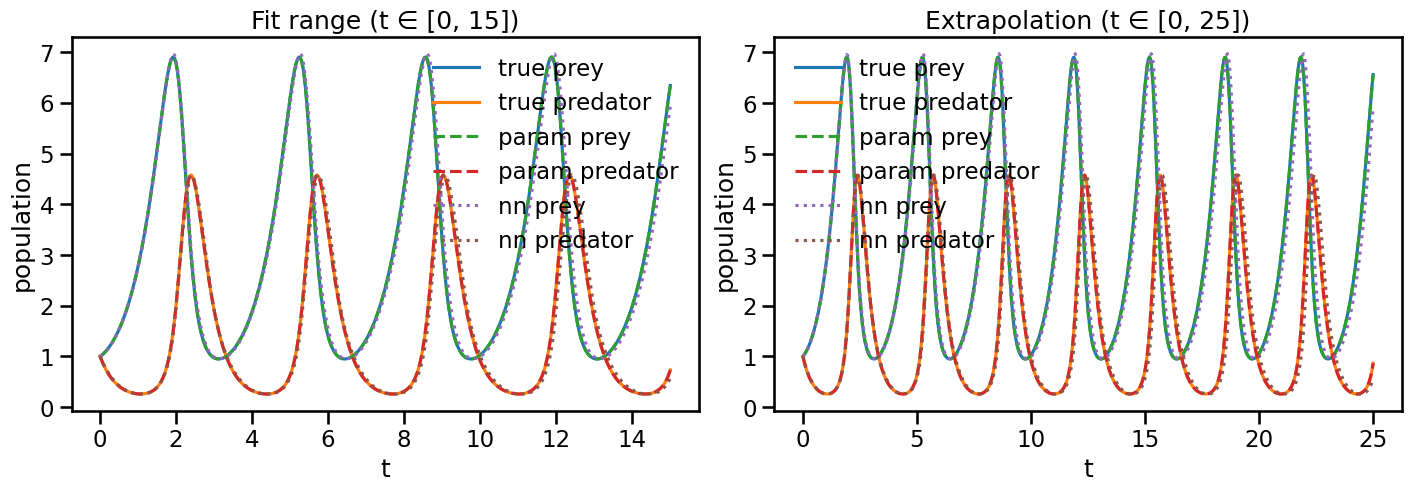

In [19]:
ts15 = jnp.linspace(0.0, 15.0, 400)
ts25 = jnp.linspace(0.0, 25.0, 600)

sol_true_15 = solve_lv(true_params, y0, (ts15[0], ts15[-1]), saveat_ts=ts15)
sol_par_15  = solve_lv(learned_params, y0, (ts15[0], ts15[-1]), saveat_ts=ts15)
sol_nn_15   = solve_nn(nn_model, y0, (ts15[0], ts15[-1]), saveat_ts=ts15)

sol_true_25 = solve_lv(true_params, y0, (ts25[0], ts25[-1]), saveat_ts=ts25)
sol_par_25  = solve_lv(learned_params, y0, (ts25[0], ts25[-1]), saveat_ts=ts25)
sol_nn_25   = solve_nn(nn_model, y0, (ts25[0], ts25[-1]), saveat_ts=ts25)

t15 = np.asarray(sol_true_15.ts)
yT15 = np.asarray(sol_true_15.ys)
yP15 = np.asarray(sol_par_15.ys)
yN15 = np.asarray(sol_nn_15.ys)

t25 = np.asarray(sol_true_25.ts)
yT25 = np.asarray(sol_true_25.ys)
yP25 = np.asarray(sol_par_25.ys)
yN25 = np.asarray(sol_nn_25.ys)

fig, ax = plt.subplots(1, 2, figsize=(14, 4.8), constrained_layout=True)

ax[0].plot(t15, yT15[:, 0], label="true prey")
ax[0].plot(t15, yT15[:, 1], label="true predator")
ax[0].plot(t15, yP15[:, 0], "--", label="param prey")
ax[0].plot(t15, yP15[:, 1], "--", label="param predator")
ax[0].plot(t15, yN15[:, 0], ":", label="nn prey")
ax[0].plot(t15, yN15[:, 1], ":", label="nn predator")
ax[0].set_title("Fit range (t ∈ [0, 15])")
ax[0].set_xlabel("t")
ax[0].set_ylabel("population")
ax[0].legend(frameon=False)

ax[1].plot(t25, yT25[:, 0], label="true prey")
ax[1].plot(t25, yT25[:, 1], label="true predator")
ax[1].plot(t25, yP25[:, 0], "--", label="param prey")
ax[1].plot(t25, yP25[:, 1], "--", label="param predator")
ax[1].plot(t25, yN25[:, 0], ":", label="nn prey")
ax[1].plot(t25, yN25[:, 1], ":", label="nn predator")
ax[1].set_title("Extrapolation (t ∈ [0, 25])")
ax[1].set_xlabel("t")
ax[1].set_ylabel("population")
ax[1].legend(frameon=False)

plt.show()

Across the fit range, both approaches demonstrate their ability to follow the trajectory closely. In the functional form, the Lotka-Volterra equation represents the correct simulation dynamic (i.e. linear growth/decay, coupled system) so learning is as simple as identifying four scalars. This approach is interpretable and efficient, making training easier. On the other hand, the Neural ODE (NODE) learns a general vector field with several degrees of freedom, offering strong interpolation. However, this method is less interpretable and potentially less robust since the system dynamics aren't constrained as they are in the functional case.

In the extrapolation case, the functional form will preserve the system dynamics as they are represented in the equation properties. In the NODE case, the vector field is constructed via training on the explored state space, so outside of the state space (in the case of extrapolation) there could be phase drift or unphysical behaviours (such as negative populations).

Parameter estimation is preferred when the system dynamics can be governed by a series of equations, or when interpretability and uncertainty is imperative. A NODE is best when system dynamics are unknown, predictive accuracy is the most important factor and there is enough data to learn from.

### Extension Question 1

**Investigate training stability improvements for Neural ODEs.**

Neural ODE training can be unstable. Try one or more of the following improvements and discuss the results:

1. **Curriculum learning**: Start training on short time spans and gradually increase
2. **Multiple shooting**: Instead of integrating over the full trajectory from a single initial condition, break it into shorter segments each with their own initial conditions, and add penalty terms that enforce continuity between segments. See [this tutorial](https://slowandsteadybrain.medium.com/how-to-4-mulitple-shooting-with-diffeqflux-jl-9ec91fd838d7) for a detailed explanation.
3. **Regularization**: Add L2 regularization on network weights

<div align="right">[10 points]</div>

In [20]:
# come back here

## Part 2: Solving PDEs with Neural Networks

Neural networks can also be used to solve partial differential equations. In this section we consider Poisson's equation in 2D:

$$
\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} = f(x, y)
$$

on $(x, y) \in [0, 1]^2$ with Dirichlet boundary conditions:

$$
\begin{align}
u(0, y) &= f_0(y) \\
u(1, y) &= f_1(y) \\
u(x, 0) &= g_0(x) \\
u(x, 1) &= g_1(x)
\end{align}
$$

We use a trial solution of the form:

$$
\hat{u}(x, y; \mathbf{w}) = A(x, y) + x(1-x)y(1-y)N(x, y; \mathbf{w})
$$

where $A(x, y)$ is constructed to satisfy the boundary conditions and $N(x, y; \mathbf{w})$ is a neural network. The factor $x(1-x)y(1-y)$ ensures the NN contribution vanishes on all boundaries.

The boundary-satisfying function $A(x, y)$ is given by:

$$
A(x,y) = (1-x)f_0(y) + xf_1(y) + (1-y)\left[g_0(x) - (1-x)g_0(0) - xg_0(1)\right] + y\left[g_1(x) - (1-x)g_1(0) - xg_1(1)\right]
$$

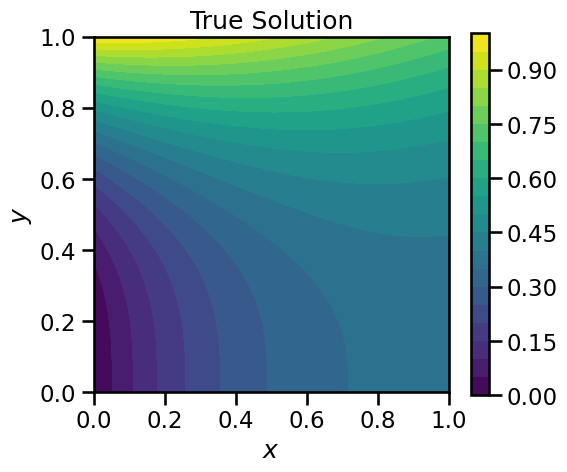

In [21]:
# Specific PDE: f(x,y) = exp(-x)(x - 2 + y^3 + 6y)
# with solution: u(x,y) = exp(-x)(x + y^3)

rhs = lambda x: jnp.exp(-x[0]) * (x[0] - 2.0 + x[1] ** 3 + 6.0 * x[1])
f0  = lambda x2: x2 ** 3
f1  = lambda x2: (1.0 + x2 ** 3) * jnp.exp(-1)
g0  = lambda x1: x1 * jnp.exp(-x1)
g1  = lambda x1: jnp.exp(-x1) * (x1 + 1.0)

def true_sol(x):
    """True solution: u(x,y) = exp(-x)(x + y^3)"""
    return jnp.exp(-x[0]) * (x[0] + x[1] ** 3)

def plot_contour(true_sol, pde_solution=None, N_grid=64):
    """Plot true solution and optionally NN solution with error."""
    xx = np.linspace(0, 1, N_grid)
    X, Y = np.meshgrid(xx, xx)
    X_flat = jnp.hstack([X.flatten()[:, None], Y.flatten()[:, None]])

    Z_t_flat = jax.vmap(true_sol)(X_flat)
    Z_t = Z_t_flat.reshape(N_grid, N_grid)

    if pde_solution is not None:
        Z_flat = jax.vmap(pde_solution)(X_flat)
        Z = Z_flat.reshape(N_grid, N_grid)
        error = jnp.abs(Z - Z_t)

        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

        c1 = ax1.contourf(X, Y, Z_t, levels=20)
        ax1.set(title="True Solution", aspect="equal", xlabel="$x$", ylabel="$y$")
        plt.colorbar(c1, ax=ax1)

        c2 = ax2.contourf(X, Y, Z, levels=20)
        ax2.set(title="Neural Network Solution", aspect="equal", xlabel="$x$", ylabel="$y$")
        plt.colorbar(c2, ax=ax2)

        c3 = ax3.contourf(X, Y, error, levels=20)
        ax3.set(title=f"Absolute Error (max={error.max():.2e})", aspect="equal", xlabel="$x$", ylabel="$y$")
        plt.colorbar(c3, ax=ax3)
    else:
        fig, ax1 = plt.subplots(1, 1, figsize=(6, 5))
        c1 = ax1.contourf(X, Y, Z_t, levels=20)
        ax1.set(title="True Solution", aspect="equal", xlabel="$x$", ylabel="$y$")
        plt.colorbar(c1, ax=ax1)

    plt.tight_layout()

# Show the true solution
plot_contour(true_sol)

### Question 2.a

**Implement the trial solution and PDE loss function.**

Complete the `PDEProblem` class below with the `A()` and `solution()` methods, then implement the loss function that measures how well the PDE is satisfied.

**Hints:**
- `A()` and `solution()` should match the definitions above
- [jax.hessian()](https://docs.jax.dev/en/latest/_autosummary/jax.hessian.html) will be useful for completing the loss function. You'll also need `jax.vmap()`

<div align="right">[10 points]</div>

In [22]:
class PDEProblem:
    """Represents a 2D Poisson equation with Dirichlet boundary conditions."""

    def __init__(self, rhs, f0, f1, g0, g1):
        self.rhs = rhs
        self.f0, self.f1 = f0, f1
        self.g0, self.g1 = g0, g1

        # Precompute corner values
        self.g00 = float(g0(jnp.array(0.0)))
        self.g01 = float(g0(jnp.array(1.0)))
        self.g10 = float(g1(jnp.array(0.0)))
        self.g11 = float(g1(jnp.array(1.0)))

    def A(self, x):
        x1, x2 = x[0], x[1]
        g00 = jnp.asarray(self.g00)
        g01 = jnp.asarray(self.g01)
        g10 = jnp.asarray(self.g10)
        g11 = jnp.asarray(self.g11)

        return ((1.0 - x1) * self.f0(x2) + x1 * self.f1(x2)
                + (1.0 - x2) * (self.g0(x1) - (1.0 - x1) * g00 - x1 * g01)
                + x2 * (self.g1(x1) - (1.0 - x1) * g10 - x1 * g11))

    def solution(self, model, x):
        x1, x2 = x[0], x[1]
        n = model(x)
        n = n.squeeze() if hasattr(n, "squeeze") else n
        return self.A(x) + x1 * (1.0 - x1) * x2 * (1.0 - x2) * n

def pde_loss(model, pde, X):
    def residual(x):
        hess = jax.hessian(lambda z: pde.solution(model, z))(x)
        lap = hess[0, 0] + hess[1, 1]
        return lap - pde.rhs(x)

    r = jax.vmap(residual)(X)
    return jnp.mean(r ** 2)

In [23]:
# Test the PDE setup
pde = PDEProblem(rhs, f0, f1, g0, g1)

# Test boundary conditions are satisfied by A alone
test_points = [
    (jnp.array([0.0, 0.5]), f0(0.5)),  # left boundary
    (jnp.array([1.0, 0.5]), f1(0.5)),  # right boundary
    (jnp.array([0.5, 0.0]), g0(0.5)),  # bottom boundary
    (jnp.array([0.5, 1.0]), g1(0.5)),  # top boundary
]

for x, expected in test_points:
    assert jnp.abs(pde.A(x) - expected) < 1e-6, f"Boundary condition not satisfied at {x}"

# Create a test model
key = jax.random.PRNGKey(0)
test_model = eqx.nn.MLP(in_size=2, out_size="scalar", width_size=10, depth=1,
                         activation=jax.nn.sigmoid, key=key)

# Test that solution satisfies BCs (NN contribution should vanish on boundaries)
for x, expected in test_points:
    sol_val = pde.solution(test_model, x)
    assert jnp.abs(sol_val - expected) < 1e-6, f"Solution BC not satisfied at {x}"

### Question 2.b

**Train the neural network to solve the PDE.**

Create an MLP with 2 inputs, scalar output, one hidden layer with 10 units and sigmoid activations. Train it using Adam to minimize the PDE residual loss on a $10 \times 10$ grid of interior points.

<div align="right">[10 points]</div>

In [24]:
pde = PDEProblem(rhs, f0, f1, g0, g1)

interior_axis = jnp.linspace(0.0, 1.0, 12)[1:-1]
x_coords, y_coords = jnp.meshgrid(interior_axis, interior_axis, indexing="ij")
interior_points = jnp.stack([x_coords.reshape(-1), y_coords.reshape(-1)], axis=1)

key = jax.random.PRNGKey(0)
key, mkey = jax.random.split(key)

pde_model = eqx.nn.MLP(
    in_size=2,
    out_size="scalar",
    width_size=10,
    depth=1,
    activation=jax.nn.sigmoid,
    final_activation=lambda z: z,
    key=mkey,
)

optim = adam(1e-3)
opt_state = optim.init(eqx.filter(pde_model, eqx.is_inexact_array))

@eqx.filter_jit
def make_step(pde_model, opt_state, collocation_points):
    loss_value, grads = eqx.filter_value_and_grad(lambda m: pde_loss(m, pde, collocation_points))(pde_model)
    updates, opt_state = optim.update(grads, opt_state, eqx.filter(pde_model, eqx.is_inexact_array))
    pde_model = eqx.apply_updates(pde_model, updates)
    return pde_model, opt_state, loss_value

loss_history = []
n_steps = 5000

for step in tqdm(range(n_steps)):
    pde_model, opt_state, loss_value = make_step(pde_model, opt_state, interior_points)
    loss_history.append(float(loss_value))
    if step % 500 == 0:
        print(f"step {step}: loss = {loss_value:.6e}")

  0%|          | 0/5000 [00:00<?, ?it/s]

step 0: loss = 1.640523e-01
step 500: loss = 3.961981e-03
step 1000: loss = 3.702678e-04
step 1500: loss = 1.686804e-04
step 2000: loss = 1.543508e-04
step 2500: loss = 1.389391e-04
step 3000: loss = 1.195016e-04
step 3500: loss = 9.508356e-05
step 4000: loss = 6.633456e-05
step 4500: loss = 3.886585e-05


In [25]:
# Test that the solution is accurate at several points
test_points = jnp.array([
    [0.25, 0.25],
    [0.5, 0.5],
    [0.75, 0.75],
    [0.25, 0.75],
    [0.75, 0.25]
])

def pde_sol(x):
    return pde.solution(pde_model, x)

nn_values = jax.vmap(pde_sol)(test_points)
true_values = jax.vmap(true_sol)(test_points)

max_error = jnp.abs(nn_values - true_values).max()
assert max_error < 0.01, f"Maximum error {max_error} exceeds tolerance"

### Question 2.c

**Visualize the solution and discuss the results.**

Use the provided `plot_contour()` function to visualize the true solution, neural network solution, and error.

Discuss:
- How well does the NN approximate the true solution?
- Where are the errors largest and why?
- What are the advantages and limitations of this approach compared to traditional numerical methods?

<div align="right">[10 points]</div>

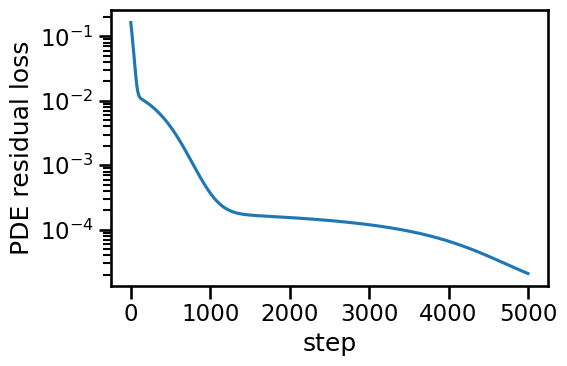

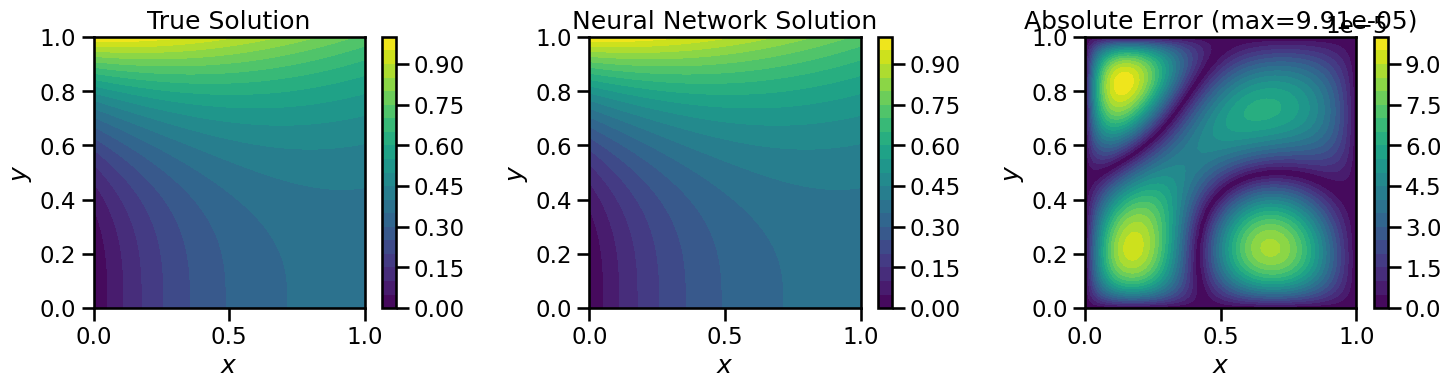

In [26]:
plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.yscale("log")
plt.xlabel("step")
plt.ylabel("PDE residual loss")
plt.tight_layout()
plt.show()

pde_solution = lambda point: pde.solution(pde_model, point)
plot_contour(true_sol, pde_solution)

The NN solution plot closely resembles the true solution, with a residual loss reaching the $10^{-5}$ mark by the end of thhe training period. The absolute error shows a maximum error of `9.91e-05`, showing high accuracy. The error is significant in interior segments since the solution uses Dirichlet boundary conditions on the analytical term $A(x,y)$ and the factor $x(1-x)y(1-y)$, suppressing the boundary error. Where there's high curvature, specifically by the $y^3$ term, residual error is higher. This could be a result of approximation errors that are amplified through automatic differentiation. The NN solution offers a differentiable surrogate that can be evaluated at valid points without having to solve a linear system as opposed to using finite-difference methods. However, the NN method suffers from non-convex optimisation and architectural sensitivities (i.e. learning rate, point placement, etc.). Nevertheless, computing the Laplacian's Hessian can be computationally expensive and prone to error propagation. This suggests that for lower dimensional problems, numerical methods are preferred, and for higher dimensional problems, the NN surrogate offers a reliable solution.

### Extension Question 2

**Investigate the effect of different network architectures or training strategies.**

Try one or more of the following:

1. **Larger networks**: Try deeper or wider networks and compare accuracy
2. **Different activation functions**: Compare sigmoid, tanh, and ReLU activations
3. **More training points**: Investigate how solution accuracy scales with training grid density
4. **Different boundary conditions**: Modify the boundary functions to create a different PDE problem

<div align="right">[10 points]</div>

  0%|          | 0/3000 [00:00<?, ?it/s]

step 0: loss=2.513040e-01
step 1000: loss=1.060303e-03
step 2000: loss=1.733712e-04


  0%|          | 0/3000 [00:00<?, ?it/s]

step 0: loss=6.453657e-02
step 1000: loss=1.690862e-04
step 2000: loss=5.137176e-05


  0%|          | 0/3000 [00:00<?, ?it/s]

step 0: loss=7.460009e-02
step 1000: loss=1.428545e-04
step 2000: loss=9.774933e-05


  0%|          | 0/3000 [00:00<?, ?it/s]

step 0: loss=7.116809e-02
step 1000: loss=6.593330e-05
step 2000: loss=9.705499e-06


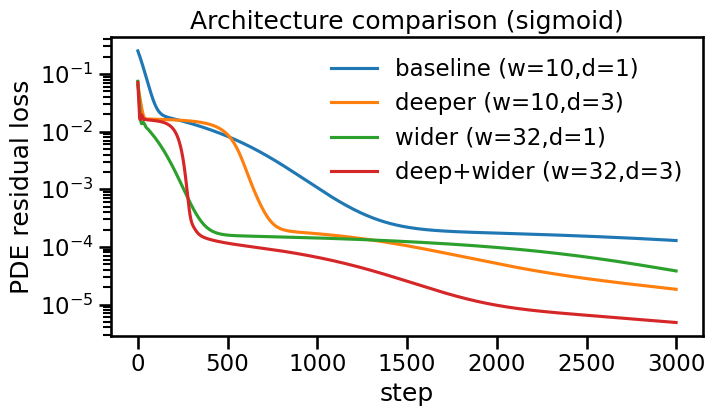

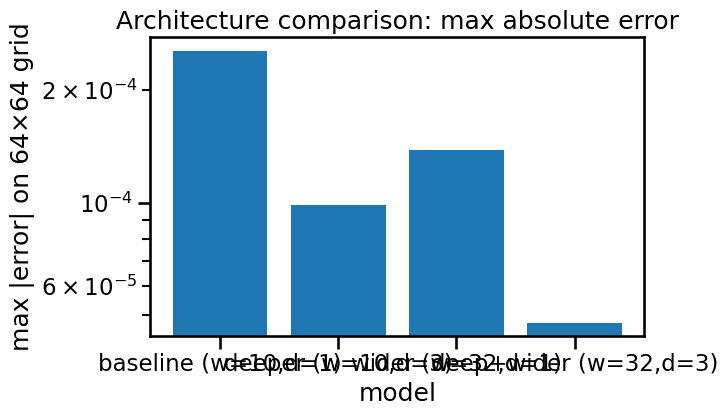

Best architecture: deep+wider (w=32,d=3) max|error|= 4.780424658118454e-05


  0%|          | 0/3000 [00:00<?, ?it/s]

step 0: loss=1.497289e-01
step 1000: loss=9.692184e-05
step 2000: loss=1.927530e-05


  0%|          | 0/3000 [00:00<?, ?it/s]

step 0: loss=1.242675e-01
step 1000: loss=1.326911e-05
step 2000: loss=4.615750e-06


  0%|          | 0/3000 [00:00<?, ?it/s]

step 0: loss=2.289742e-01
step 1000: loss=3.773510e-05
step 2000: loss=2.549192e-05


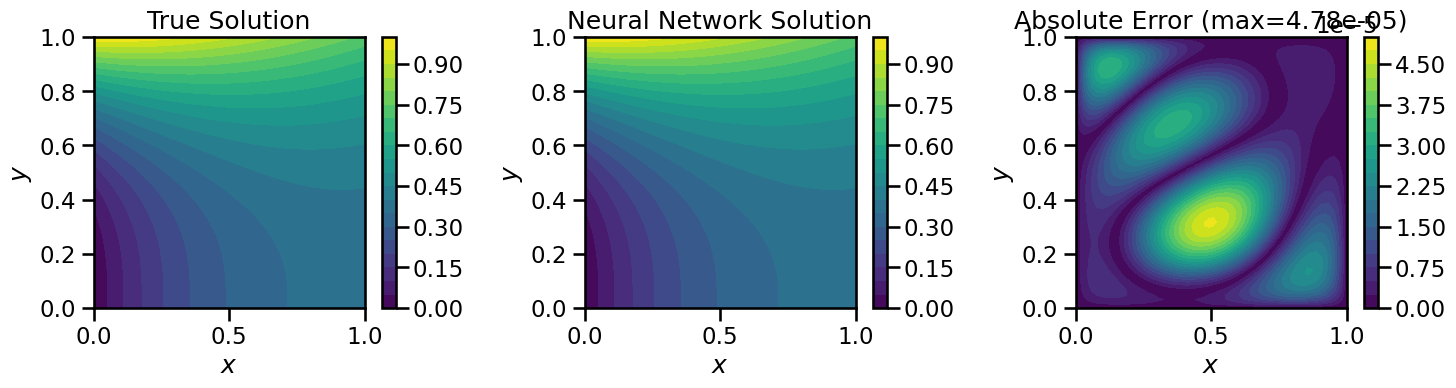

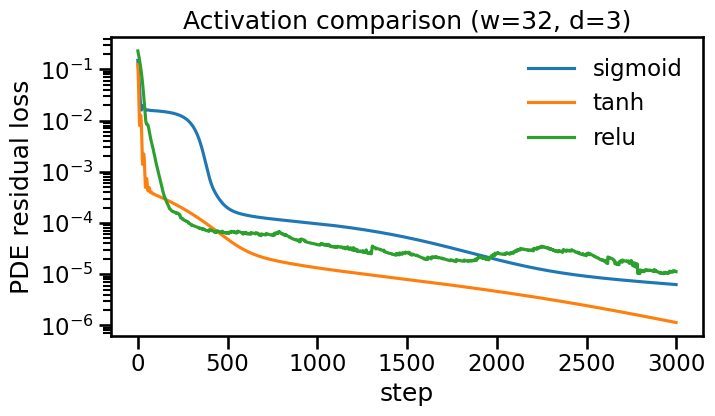

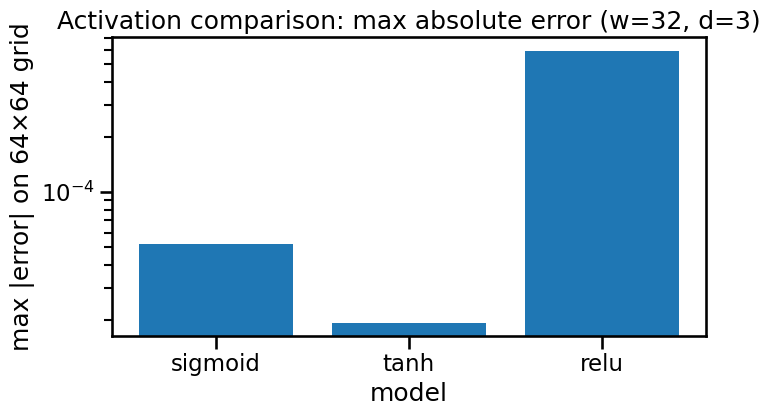

Best activation: tanh max|error|= 1.93442042026315e-05


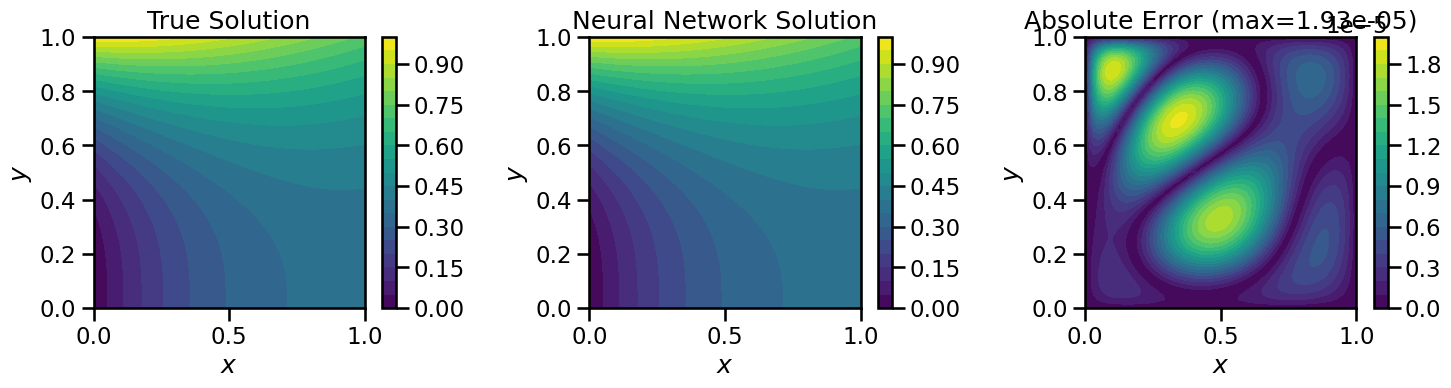

In [27]:
pde = PDEProblem(rhs, f0, f1, g0, g1)

def make_collocation_points(n_per_axis=10):
    axis = jnp.linspace(0.0, 1.0, n_per_axis + 2)[1:-1]
    x_grid, y_grid = jnp.meshgrid(axis, axis, indexing="ij")
    return jnp.stack([x_grid.reshape(-1), y_grid.reshape(-1)], axis=1)

collocation_points = make_collocation_points(10)

def max_abs_error(pde, model, true_sol, grid_res=64):
    axis = jnp.linspace(0.0, 1.0, grid_res)
    xg, yg = jnp.meshgrid(axis, axis, indexing="ij")
    points = jnp.stack([xg.reshape(-1), yg.reshape(-1)], axis=1)
    u_true = jax.vmap(true_sol)(points)
    u_pred = jax.vmap(lambda z: pde.solution(model, z))(points)
    return float(jnp.max(jnp.abs(u_pred - u_true)))

def train_pde_model(pde, model, collocation_points, steps=3000, learning_rate=1e-3, seed=0, report_every=500):
    optim = adam(learning_rate)
    opt_state = optim.init(eqx.filter(model, eqx.is_inexact_array))

    @eqx.filter_jit
    def step_fn(model, opt_state):
        loss_value, grads = eqx.filter_value_and_grad(lambda m: pde_loss(m, pde, collocation_points))(model)
        updates, opt_state = optim.update(grads, opt_state, eqx.filter(model, eqx.is_inexact_array))
        model = eqx.apply_updates(model, updates)
        return model, opt_state, loss_value

    loss_history = []
    for i in tqdm(range(steps)):
        model, opt_state, loss_value = step_fn(model, opt_state)
        loss_history.append(float(loss_value))
        if report_every is not None and i % report_every == 0:
            print(f"step {i}: loss={loss_value:.6e}")
    return model, loss_history

def build_mlp(key, width, depth, activation):
    return eqx.nn.MLP(
        in_size=2,
        out_size="scalar",
        width_size=width,
        depth=depth,
        activation=activation,
        final_activation=lambda z: z,
        key=key,
    )

def plot_loss_curves(histories, title):
    plt.figure(figsize=(7.5, 4.5))
    for name, hist in histories.items():
        plt.plot(hist, label=name)
    plt.yscale("log")
    plt.xlabel("step")
    plt.ylabel("PDE residual loss")
    plt.title(title)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

def plot_error_bars(errors, title):
    names = list(errors.keys())
    vals = [errors[k] for k in names]
    plt.figure(figsize=(7.5, 4.5))
    plt.bar(names, vals)
    plt.yscale("log")
    plt.xlabel("model")
    plt.ylabel("max |error| on 64×64 grid")
    plt.title(title)
    plt.tight_layout()
    plt.show()

base_key = jax.random.PRNGKey(0)

arch_specs = {
    "baseline (w=10,d=1)": dict(width=10, depth=1),
    "deeper (w=10,d=3)": dict(width=10, depth=3),
    "wider (w=32,d=1)": dict(width=32, depth=1),
    "deep+wider (w=32,d=3)": dict(width=32, depth=3),
}

arch_histories = {}
arch_errors = {}
arch_models = {}

for i, (name, spec) in enumerate(arch_specs.items()):
    key_i = jax.random.fold_in(base_key, i)
    model_i = build_mlp(key_i, width=spec["width"], depth=spec["depth"], activation=jax.nn.sigmoid)
    model_i, hist_i = train_pde_model(pde, model_i, collocation_points, steps=3000, learning_rate=1e-3, report_every=1000)
    arch_histories[name] = hist_i
    arch_models[name] = model_i
    arch_errors[name] = max_abs_error(pde, model_i, true_sol, grid_res=64)

plot_loss_curves(arch_histories, "Architecture comparison (sigmoid)")
plot_error_bars(arch_errors, "Architecture comparison: max absolute error")

best_arch_name = min(arch_errors, key=arch_errors.get)
best_arch_model = arch_models[best_arch_name]
print("Best architecture:", best_arch_name, "max|error|=", arch_errors[best_arch_name])
plot_contour(true_sol, lambda z: pde.solution(best_arch_model, z))

activation_specs = {
    "sigmoid": jax.nn.sigmoid,
    "tanh": jax.nn.tanh,
    "relu": jax.nn.relu,
}

act_histories = {}
act_errors = {}
act_models = {}

best_width = 32
best_depth = 3

for j, (name, act_fn) in enumerate(activation_specs.items()):
    key_j = jax.random.fold_in(base_key, 100 + j)
    model_j = build_mlp(key_j, width=best_width, depth=best_depth, activation=act_fn)
    model_j, hist_j = train_pde_model(pde, model_j, collocation_points, steps=3000, learning_rate=1e-3, report_every=1000)
    act_histories[name] = hist_j
    act_models[name] = model_j
    act_errors[name] = max_abs_error(pde, model_j, true_sol, grid_res=64)

plot_loss_curves(act_histories, f"Activation comparison (w={best_width}, d={best_depth})")
plot_error_bars(act_errors, f"Activation comparison: max absolute error (w={best_width}, d={best_depth})")

best_act_name = min(act_errors, key=act_errors.get)
best_act_model = act_models[best_act_name]
print("Best activation:", best_act_name, "max|error|=", act_errors[best_act_name])
plot_contour(true_sol, lambda z: pde.solution(best_act_model, z))